# =============================================================
# Assignment 4 - Generative AI (AI4009) Spring 2026
# Denoising Diffusion Probabilistic Model (DDPM)
# Dataset: CelebA-HQ 256x256
# Platform: Kaggle T4 x2 GPU
# Implementation: Base PyTorch Only
# =============================================================

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.backends.cudnn.benchmark = True

**DATASET LOADING**

In [7]:
class ImageDataset(Dataset):
    def __init__(self, root_dir, size=128):
        self.paths = []
        for img in os.listdir(root_dir):
            path = os.path.join(root_dir, img)
            if path.lower().endswith(('.png','.jpg','.jpeg')):
                self.paths.append(path)

        print(f"Loaded {len(self.paths)} images")

        if len(self.paths) == 0:
            raise ValueError("Dataset is empty. Check path!")

        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)

**DataLoader**

In [8]:
dataset = ImageDataset(
    "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train"
)

print(len(dataset))
dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

Loaded 27000 images
27000


**Diffusion Setup**

In [9]:
T = 300

beta_start = 1e-4
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1. - betas
alpha_hat = torch.cumprod(alphas, dim=0)

**Noise Schedule**

In [10]:
def add_noise(x, t):
    noise = torch.randn_like(x)

    sqrt_alpha_hat = torch.sqrt(alpha_hat[t]).view(-1,1,1,1)
    sqrt_one_minus = torch.sqrt(1 - alpha_hat[t]).view(-1,1,1,1)

    return sqrt_alpha_hat * x + sqrt_one_minus * noise, noise

**Model (U-Net)**

In [11]:
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DoubleConv(3, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        # Output
        self.out = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, x, t):
        # Encoder
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))

        # Decoder with skip connections
        x = self.up1(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv2(x)

        return self.out(x)

**Training Setup**

In [12]:
model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

epochs = 10
losses = []

**Training Loop**

In [13]:
from tqdm import tqdm

for epoch in range(epochs):
    pbar = tqdm(dataloader)

    for images in pbar:
        images = images.to(device)

        t = torch.randint(0, T, (images.size(0),), device=device)

        noisy_images, noise = add_noise(images, t)

        pred_noise = model(noisy_images, t)

        loss = loss_fn(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        losses.append(loss.item())
        pbar.set_description(f"Epoch {epoch} Loss: {loss.item():.4f}")

Epoch 9 Loss: 0.0304: 100%|██████████| 1688/1688 [03:39<00:00,  7.69it/s]


**ADD MODEL SAVING**

In [24]:
torch.save(model.state_dict(), "/kaggle/working/ddpm_model.pth")
print("Model saved successfully!")

Model saved successfully!


**LOSS GRAPH**

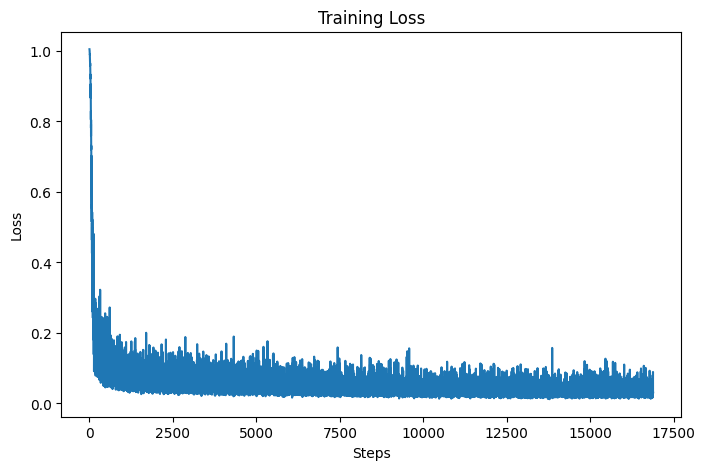

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

**SAMPLING (REVERSE DIFFUSION)**

In [16]:
@torch.no_grad()
def sample(model, n=5):
    model.eval()

    x = torch.randn((n, 3, 128, 128)).to(device)

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device)

        pred_noise = model(x, t_batch)

        alpha = alphas[t]
        alpha_hat_t = alpha_hat[t]

        x = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_hat_t)) * pred_noise
        )

    return x

**GENERATE IMAGES**

In [17]:
samples = sample(model, 5)

**SHOW GENERATED IMAGE**

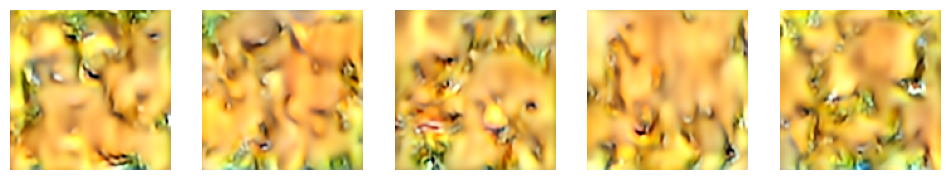

In [18]:
def show_images(imgs):
    imgs = (imgs.clamp(-1,1) + 1) / 2
    imgs = imgs.permute(0,2,3,1).cpu()

    plt.figure(figsize=(12,4))
    for i in range(len(imgs)):
        plt.subplot(1, len(imgs), i+1)
        plt.imshow(imgs[i])
        plt.axis("off")
    plt.show()

show_images(samples)

**FORWARD DIFFUSION VISUALIZATION**

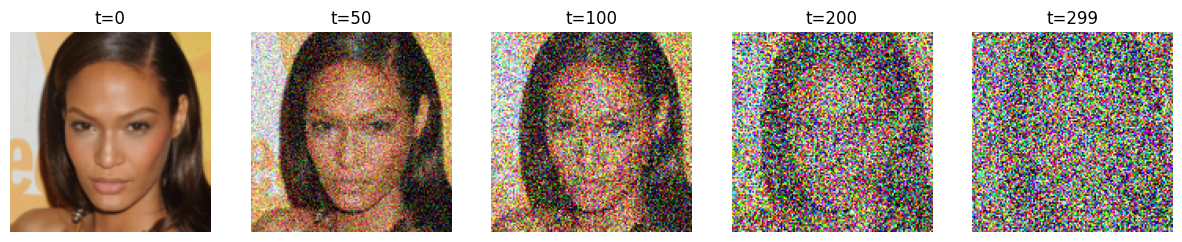

In [19]:
def show_noising(img):
    steps = [0, 50, 100, 200, 299]

    plt.figure(figsize=(15,3))
    for i, step in enumerate(steps):
        t = torch.tensor([step]).to(device)
        noisy, _ = add_noise(img.unsqueeze(0).to(device), t)

        noisy = (noisy.squeeze().clamp(-1,1) + 1) / 2
        noisy = noisy.permute(1,2,0).cpu()

        plt.subplot(1,5,i+1)
        plt.imshow(noisy)
        plt.title(f"t={step}")
        plt.axis("off")

    plt.show()

# Example
sample_img = dataset[0]
show_noising(sample_img)

**RECONSTRUCTION TASK**

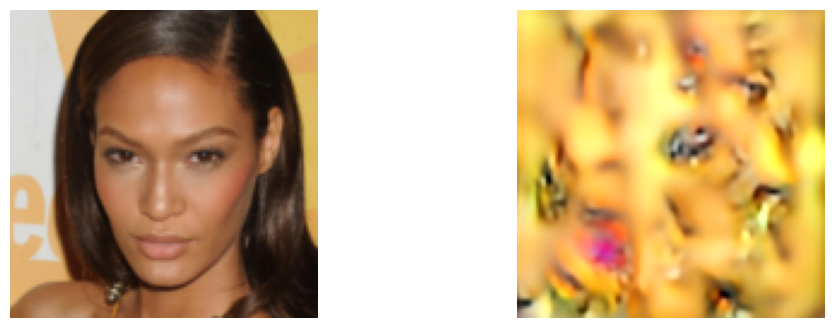

In [20]:
target = dataset[0].unsqueeze(0).to(device)

t = torch.tensor([T-1]).to(device)
noisy, _ = add_noise(target, t)

reconstructed = sample(model, 1)

show_images(torch.cat([target.cpu(), reconstructed.cpu()]))

**PSNR + SSIM**

In [21]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

def evaluate(real, fake):
    real = real.squeeze().permute(1,2,0).cpu().numpy()
    fake = fake.squeeze().permute(1,2,0).cpu().numpy()

    psnr = peak_signal_noise_ratio(real, fake, data_range=1)
    ssim = structural_similarity(real, fake, channel_axis=2, data_range=1)

    return psnr, ssim

psnr, ssim = evaluate(target, reconstructed)

print("PSNR:", psnr)
print("SSIM:", ssim)

PSNR: 1.9098005482008016
SSIM: 0.022120968


**GRADIO APP**

In [22]:
import gradio as gr

def generate():
    img = sample(model, 1)
    img = (img.clamp(-1,1) + 1) / 2
    return img[0].permute(1,2,0).cpu().numpy()

gr.Interface(fn=generate, inputs=[], outputs="image").launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://eff9316a81e84ce25d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
import os
from IPython.display import FileLink

# Verify if the file exists first
if os.path.exists("/kaggle/working/ddpm_model.pth"):
    print("✅ File found! Click the link below to download:")
    display(FileLink(r'ddpm_model.pth'))
else:
    print("❌ File not found. Check if the training cell actually finished.")

✅ File found! Click the link below to download:


/kaggle/working/ddpm_model.pth